In [1]:
# Block 1
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dropout,Conv2D, MaxPooling2D, GlobalAveragePooling2D,Flatten, Dense
import cv2


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [3]:
train_path = path + "/Training"
test_path = path + "/Testing"

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [5]:
# Block 5
print(train_data.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [6]:
# Block 6
model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),   # 🔥 Better than Flatten

    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(4,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Block 7
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
# Block 9
history = model.fit(
    train_data,
    epochs=10,
    validation_data=test_data
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 63s 322ms/step - accuracy: 0.4652 - loss: 1.1191 - val_accuracy: 0.5675 - val_loss: 1.1539
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.6313 - loss: 0.8874 - val_accuracy: 0.6569 - val_loss: 1.0524
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.7029 - loss: 0.7543 - val_accuracy: 0.6569 - val_loss: 0.9652
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - accuracy: 0.7195 - loss: 0.7032 - val_accuracy: 0.6637 - val_loss: 1.0862
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 89ms/step - accuracy: 0.7514 - loss: 0.6439 - val_accuracy: 0.6681 - val_loss: 0.9383
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - accuracy: 0.7630 - loss: 0.6107 - val_accuracy: 0.6575 - val_loss: 1.0114
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.7782 - loss: 0.5821 - val_accuracy: 0.6756 - val_loss: 0.9926
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - accuracy: 0.7879 - loss: 0.5494 -

In [9]:
# Block 10
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.6725 - loss: 0.8987
Test Accuracy: 0.6725000143051147


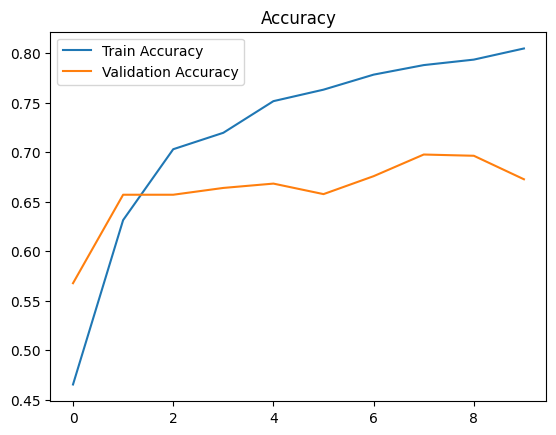

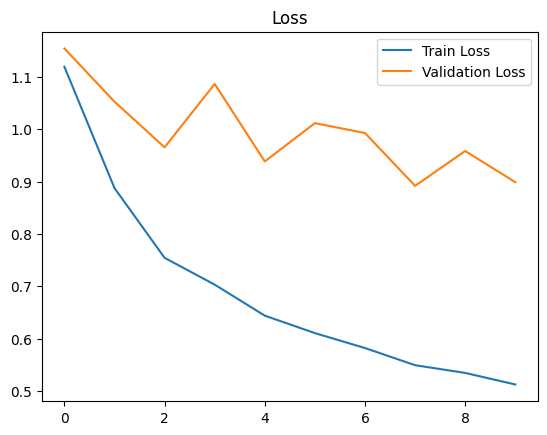

In [10]:
# Block 11
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [11]:
# Block 12
def get_gradcam(img_array, model, last_conv_layer_name):

    grad_model = Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = tf.reduce_max(predictions)

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap,0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()